ANÁLISE DE UMA LISTA DE MÚSICAS

# Conclusões da Análise de Dados Musicais

## Objetivo
O objetivo deste projeto foi analisar quais características musicais influenciam a popularidade das músicas.

## Tratamento de Dados
Durante o projeto, foi necessário realizar limpeza e tratamento dos dados, pois o dataset apresentava problemas como:
- Colunas desorganizadas
- Valores ausentes
- Tipos de dados incorretos
- Linhas inválidas
- Presença de outliers

Após o tratamento, os dados puderam ser analisados corretamente.

## Análise Exploratória
Foram utilizados gráficos de dispersão, histograma, boxplot e análise de correlação para entender a relação entre as variáveis musicais e a popularidade.

## Resultados
A análise mostrou que:
- A maioria das músicas possui popularidade baixa ou média.
- Poucas músicas possuem popularidade muito alta.
- Músicas instrumentais tendem a ser menos populares.
- Músicas mais longas tendem a ter menor popularidade.
- Músicas com BPM mais alto tendem a ter menor popularidade.
- Danceability e Energy apresentam alguma relação com a popularidade, mas não são fatores determinantes sozinhos.

## Conclusão Final
A popularidade de uma música não depende de apenas uma característica, mas de um conjunto de fatores. A análise de dados permitiu identificar padrões e entender melhor o comportamento das músicas em relação à popularidade.

Este projeto demonstrou a importância da limpeza de dados, da análise exploratória e da visualização de dados para a geração de insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Criar pasta de gráficos automaticamente
os.makedirs('graficos', exist_ok=True)

print("Ambiente pronto. Pasta 'graficos' conectada.")

Ambiente pronto. Pasta 'graficos' conectada.


In [2]:
import pandas as pd
df = pd.read_excel('ClassicDisco.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 2 columns):
 #   Column                                                                                                                                                             Non-Null Count  Dtype 
---  ------                                                                                                                                                             --------------  ----- 
 0   Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity  724 non-null    object
 1   Unnamed: 1                                                                                                                                                         3 non-null      object
dtypes: object(2)
memory usage: 11.4+ KB


In [3]:
df['Unnamed: 1']

#👉 Isso vai mostrar a coluna inteira


0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
      ... 
719    NaN
720    NaN
721    NaN
722    NaN
723    NaN
Name: Unnamed: 1, Length: 724, dtype: object

In [4]:
df['Unnamed: 1'].head(10)

#👉 Ver só as primeiras 10 linhas

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
Name: Unnamed: 1, dtype: object

In [5]:
df['Unnamed: 1'].value_counts(dropna=False)

#👉 Isso mostra: quantos valores existem e quantos são nulos (NaN)

Unnamed: 1
NaN                                                                                                                                          721
 Single Mix,Curtis Mayfield,Superfly (Original Soundtrack), 1972,200720,4,0.49,0.86,1,-5.657,0,0.097,0.0188,0.0271,0.0756,0.803,90.464,25      1
s Go Disco,The Real Thing,The Real Thing, 1978,203160,4,0.871,0.52,11,-11.952,0,0.128,0.082,0.00378,0.0753,0.63,112.823,1                      1
 DJ Spinna ReFreak)", 1981,460438,4,0.808,0.478,7,-10.081,0,0.0403,0.00158,0.081,0.0984,0.72,117.004,20                                        1
Name: count, dtype: int64

drop → remove

columns → estamos removendo coluna

inplace=True → altera o próprio df

In [6]:
df.drop(columns=['Unnamed: 1'], inplace=True)

In [7]:
df.shape

(724, 1)

In [8]:
df.head()

,"Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity"
0,"Boogie Oogie Oogie,A Taste Of Honey,A Taste Of..."
1,"Disco Dancin' - 2004 - Remastered,A Taste Of H..."
2,"Distant,A Taste Of Honey,A Taste Of Honey, 197..."
3,"Do It Good,A Taste Of Honey,Another Taste (Exp..."
4,"If We Loved,A Taste Of Honey,A Taste Of Honey,..."


In [9]:
df.columns

Index(['Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity'], dtype='object')

In [10]:
df_separado = df[df.columns[0]].str.split(',', expand=True)


In [11]:
df_separado.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,Boogie Oogie Oogie,A Taste Of Honey,A Taste Of Honey,1978,245173,4,0.797,0.548,2,-9.228,...,0.0994,0.868,123.686,53,None,None,None,None,None,None
1,Disco Dancin' - 2004 - Remastered,A Taste Of Honey,A Taste Of Honey,1978,210493,4,0.751,0.57,2,-11.645,...,0.123,0.77,103.408,11,None,None,None,None,None,None
2,Distant,A Taste Of Honey,A Taste Of Honey,1978,260053,4,0.468,0.512,2,-10.187,...,0.202,0.714,163.4,13,None,None,None,None,None,None
3,Do It Good,A Taste Of Honey,Another Taste (Expanded Edition),1978,342826,4,0.699,0.74,3,-8.625,...,0.165,0.889,104.168,17,None,None,None,None,None,None
4,If We Loved,A Taste Of Honey,A Taste Of Honey,1978,266200,4,0.463,0.459,6,-11.6,...,0.158,0.3,129.267,13,None,None,None,None,None,None


In [12]:
df_separado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       724 non-null    object
 1   1       722 non-null    object
 2   2       722 non-null    object
 3   3       722 non-null    object
 4   4       722 non-null    object
 5   5       721 non-null    object
 6   6       721 non-null    object
 7   7       721 non-null    object
 8   8       721 non-null    object
 9   9       721 non-null    object
 10  10      721 non-null    object
 11  11      721 non-null    object
 12  12      721 non-null    object
 13  13      721 non-null    object
 14  14      721 non-null    object
 15  15      721 non-null    object
 16  16      721 non-null    object
 17  17      721 non-null    object
 18  18      68 non-null     object
 19  19      18 non-null     object
 20  20      5 non-null      object
 21  21      2 non-null      object
 22  22      1 non-null      ob

In [13]:
df_separado.iloc[:,18:24]

,18,19,20,21,22,23
0,None,None,None,None,None,None
1,None,None,None,None,None,None
2,None,None,None,None,None,None
3,None,None,None,None,None,None
4,None,None,None,None,None,None
...,...,...,...,...,...,...
719,23,None,None,None,None,None
720,None,None,None,None,None,None
721,None,None,None,None,None,None
722,None,None,None,None,None,None


In [14]:
df_separado = df_separado.iloc[:, :18]

In [15]:
df_separado.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Boogie Oogie Oogie,A Taste Of Honey,A Taste Of Honey,1978,245173,4,0.797,0.548,2,-9.228,0,0.0492,0.0401,0.0000105,0.0994,0.868,123.686,53
1,Disco Dancin' - 2004 - Remastered,A Taste Of Honey,A Taste Of Honey,1978,210493,4,0.751,0.57,2,-11.645,1,0.0813,0.371,0.0000204,0.123,0.77,103.408,11
2,Distant,A Taste Of Honey,A Taste Of Honey,1978,260053,4,0.468,0.512,2,-10.187,1,0.138,0.782,0.0000201,0.202,0.714,163.4,13
3,Do It Good,A Taste Of Honey,Another Taste (Expanded Edition),1978,342826,4,0.699,0.74,3,-8.625,0,0.0289,0.0714,0.0000019,0.165,0.889,104.168,17
4,If We Loved,A Taste Of Honey,A Taste Of Honey,1978,266200,4,0.463,0.459,6,-11.6,1,0.0296,0.764,0.00000288,0.158,0.3,129.267,13


In [16]:
df.columns[0].split(',')

['Track',
 'Artist',
 'Album',
 'Year',
 'Duration',
 'Time_Signature',
 'Danceability',
 'Energy',
 'Key',
 'Loudness',
 'Mode',
 'Speechiness',
 'Acousticness',
 'Instrumentalness',
 'Liveness',
 'Valence',
 'Tempo',
 'Popularity']

In [17]:
nomes_colunas = df.columns[0].split(',')

In [18]:
df_separado.columns = nomes_colunas

In [19]:
len(nomes_colunas)

18

In [20]:
df_separado.head()

,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
0,Boogie Oogie Oogie,A Taste Of Honey,A Taste Of Honey,1978,245173,4,0.797,0.548,2,-9.228,0,0.0492,0.0401,0.0000105,0.0994,0.868,123.686,53
1,Disco Dancin' - 2004 - Remastered,A Taste Of Honey,A Taste Of Honey,1978,210493,4,0.751,0.57,2,-11.645,1,0.0813,0.371,0.0000204,0.123,0.77,103.408,11
2,Distant,A Taste Of Honey,A Taste Of Honey,1978,260053,4,0.468,0.512,2,-10.187,1,0.138,0.782,0.0000201,0.202,0.714,163.4,13
3,Do It Good,A Taste Of Honey,Another Taste (Expanded Edition),1978,342826,4,0.699,0.74,3,-8.625,0,0.0289,0.0714,0.0000019,0.165,0.889,104.168,17
4,If We Loved,A Taste Of Honey,A Taste Of Honey,1978,266200,4,0.463,0.459,6,-11.6,1,0.0296,0.764,0.00000288,0.158,0.3,129.267,13


In [21]:
df_separado.tail()

,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
719,Lady America,Voyage,"""Twelve Inch Classics from the 70s","Vol. 2""",1979,407800,4,0.649,0.84,5,-7.713,1,0.0411,0.000681,0.00658,0.375,0.921,128.02
720,Let's Fly Away,Voyage,Fly Away,1979,306818,4,0.709,0.854,8,-4.75,1,0.0348,0.0506,0.0000547,0.624,0.9,129.258,15
721,Scotch Machine,Voyage,Voyage,1979,208200,4,0.633,0.901,10,-10.248,1,0.0325,0.000343,0.909,0.0533,0.862,129.173,20
722,Souvenirs,Voyage,Fly Away,1979,390567,4,0.633,0.97,5,-4.153,1,0.038,0.000667,0.202,0.396,0.757,127.776,29
723,Tahiti,Tahitiâ€¦,Voyage,Fly Away,1979,299510,4,0.672,0.972,2,-4.929,1,0.139,0.00425,0.00000912,0.101,0.815,127.591


In [22]:
df_separado.dtypes

Track               object
Artist              object
Album               object
Year                object
Duration            object
Time_Signature      object
Danceability        object
Energy              object
Key                 object
Loudness            object
Mode                object
Speechiness         object
Acousticness        object
Instrumentalness    object
Liveness            object
Valence             object
Tempo               object
Popularity          object
dtype: object

In [23]:
df_traduzido = df_separado.rename(columns={
    'Track':'musica',
    'Year':'ano',
    'Loudness':'intensidade_sonora',
    'Key':'tonalidade'
})

In [24]:
df_traduzido.head()

,musica,Artist,Album,ano,Duration,Time_Signature,Danceability,Energy,tonalidade,intensidade_sonora,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
0,Boogie Oogie Oogie,A Taste Of Honey,A Taste Of Honey,1978,245173,4,0.797,0.548,2,-9.228,0,0.0492,0.0401,0.0000105,0.0994,0.868,123.686,53
1,Disco Dancin' - 2004 - Remastered,A Taste Of Honey,A Taste Of Honey,1978,210493,4,0.751,0.57,2,-11.645,1,0.0813,0.371,0.0000204,0.123,0.77,103.408,11
2,Distant,A Taste Of Honey,A Taste Of Honey,1978,260053,4,0.468,0.512,2,-10.187,1,0.138,0.782,0.0000201,0.202,0.714,163.4,13
3,Do It Good,A Taste Of Honey,Another Taste (Expanded Edition),1978,342826,4,0.699,0.74,3,-8.625,0,0.0289,0.0714,0.0000019,0.165,0.889,104.168,17
4,If We Loved,A Taste Of Honey,A Taste Of Honey,1978,266200,4,0.463,0.459,6,-11.6,1,0.0296,0.764,0.00000288,0.158,0.3,129.267,13


In [25]:
df_traduzido.dtypes

musica                object
Artist                object
Album                 object
ano                   object
Duration              object
Time_Signature        object
Danceability          object
Energy                object
tonalidade            object
intensidade_sonora    object
Mode                  object
Speechiness           object
Acousticness          object
Instrumentalness      object
Liveness              object
Valence               object
Tempo                 object
Popularity            object
dtype: object

In [26]:
#21/03/2026

colunas_float = [
    'Danceability',
    'Energy',
    'intensidade_sonora',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Liveness',
    'Valence',
    'Tempo'
]

In [27]:
for coluna in colunas_float:
    df_traduzido[coluna] = pd.to_numeric(df_traduzido[coluna], errors='coerce')

In [28]:
df_traduzido.dtypes

musica                 object
Artist                 object
Album                  object
ano                    object
Duration               object
Time_Signature         object
Danceability          float64
Energy                float64
tonalidade             object
intensidade_sonora    float64
Mode                   object
Speechiness           float64
Acousticness          float64
Instrumentalness      float64
Liveness              float64
Valence               float64
Tempo                 float64
Popularity             object
dtype: object

In [29]:
df_traduzido.isna().sum()

musica                0
Artist                2
Album                 2
ano                   2
Duration              2
Time_Signature        3
Danceability          5
Energy                4
tonalidade            3
intensidade_sonora    3
Mode                  3
Speechiness           3
Acousticness          3
Instrumentalness      3
Liveness              3
Valence               3
Tempo                 3
Popularity            3
dtype: int64

23/03/2026: Vamos transformar as colunas que são string em float ou int, texto em números, que ajudará-nos em análises futuras.


In [30]:
colunas_texto = ['musica', 'Artist', 'Album']

for coluna in df_traduzido.columns:
    if coluna not in colunas_texto:
        df_traduzido[coluna] = pd.to_numeric(df_traduzido[coluna], errors='coerce')

In [31]:
'''for coluna in df_traduzido.columns:
    if df_traduzido[coluna].dtype == 'object':
        df_traduzido[coluna] = pd.to_numeric(df_traduzido[coluna], errors='coerce') 
'''

"for coluna in df_traduzido.columns:\n    if df_traduzido[coluna].dtype == 'object':\n        df_traduzido[coluna] = pd.to_numeric(df_traduzido[coluna], errors='coerce') \n"

In [32]:
df_traduzido.dtypes

musica                 object
Artist                 object
Album                  object
ano                   float64
Duration              float64
Time_Signature        float64
Danceability          float64
Energy                float64
tonalidade            float64
intensidade_sonora    float64
Mode                  float64
Speechiness           float64
Acousticness          float64
Instrumentalness      float64
Liveness              float64
Valence               float64
Tempo                 float64
Popularity            float64
dtype: object

In [33]:
df_traduzido.isna().sum()

musica                 0
Artist                 2
Album                  2
ano                   71
Duration              21
Time_Signature         8
Danceability           5
Energy                 4
tonalidade             4
intensidade_sonora     3
Mode                   3
Speechiness            3
Acousticness           3
Instrumentalness       3
Liveness               3
Valence                3
Tempo                  3
Popularity             3
dtype: int64

In [34]:
for coluna in df_traduzido.columns:
    if df_traduzido[coluna].dtype == 'float64':
        mediana = df_traduzido[coluna].median()
        df_traduzido[coluna].fillna(mediana, inplace=True)

In [35]:
df_traduzido.isna().sum()

musica                0
Artist                2
Album                 2
ano                   0
Duration              0
Time_Signature        0
Danceability          0
Energy                0
tonalidade            0
intensidade_sonora    0
Mode                  0
Speechiness           0
Acousticness          0
Instrumentalness      0
Liveness              0
Valence               0
Tempo                 0
Popularity            0
dtype: int64

In [36]:
df_traduzido[df_traduzido['Artist'].isna() | df_traduzido['Album'].isna()]

,musica,Artist,Album,ano,Duration,Time_Signature,Danceability,Energy,tonalidade,intensidade_sonora,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
164,Freddie's Dead - Theme From 'Superfly',None,None,1978.0,269306.0,4.0,0.726,0.6865,5.0,-9.335,1.0,0.0492,0.101,0.00115,0.1,0.791,117.186,32.0
612,Let&apos,None,None,1978.0,269306.0,4.0,0.726,0.6865,5.0,-9.335,1.0,0.0492,0.101,0.00115,0.1,0.791,117.186,32.0


vamos armazenar essas duas linhas problemas, caso precise delas depois, e como são só 2 linhas em um banco com mais de 700, iremos apagá-las:

In [37]:
linhas_problema = df_traduzido[df_traduzido['Artist'].isna() | df_traduzido['Album'].isna()]

In [38]:
df_traduzido = df_traduzido.drop(linhas_problema.index)


In [39]:
df_traduzido.shape

(722, 18)

In [40]:
df_traduzido.isna().sum()

musica                0
Artist                0
Album                 0
ano                   0
Duration              0
Time_Signature        0
Danceability          0
Energy                0
tonalidade            0
intensidade_sonora    0
Mode                  0
Speechiness           0
Acousticness          0
Instrumentalness      0
Liveness              0
Valence               0
Tempo                 0
Popularity            0
dtype: int64

Limpamos e tratamos os dados. agora faremos as análises

In [41]:
for coluna in df_traduzido.columns:
    if df_traduzido[coluna].dtype == 'float64':
        media = df_traduzido[coluna].mean()
        print(coluna, media)

ano 1977.994459833795
Duration 280428.06925207755
Time_Signature 19874.57617728532
Danceability 5807.928757617728
Energy 983.4399364265928
tonalidade 526.8583434903047
intensidade_sonora -6.006091412742382
Mode 694.5193199445982
Speechiness -0.026962742382271462
Acousticness 0.17252990207756233
Instrumentalness 0.0846831405263158
Liveness 0.17709457477839333
Valence 0.6952686588919669
Tempo 107.67909621883656
Popularity 37.69077257617729


análises estatísticas de média, mediana, valores máximo e mínimo:

In [42]:
for coluna in df_traduzido.columns:
    if df_traduzido[coluna].dtype == 'float64' or df_traduzido[coluna].dtype == 'int64':
        media = df_traduzido[coluna].mean()
        mediana = df_traduzido[coluna].median()
        valor_maximo = df_traduzido[coluna].max()
        valor_minimo = df_traduzido[coluna].min()
        
        print(coluna, media, mediana, valor_maximo, valor_minimo)

ano 1977.994459833795 1978.0 2020.0 1967.0
Duration 280428.06925207755 269306.0 1008533.0 1967.0
Time_Signature 19874.57617728532 4.0 495773.0 3.0
Danceability 5807.928757617728 0.726 622426.0 0.293
Energy 983.4399364265928 0.6865000000000001 323546.0 0.0348
tonalidade 526.8583434903047 5.0 376866.0 0.0
intensidade_sonora -6.006091412742382 -9.335 1978.0 -23.92
Mode 694.5193199445982 1.0 501466.0 -16.66
Speechiness -0.026962742382271462 0.0492 11.0 -11.497
Acousticness 0.17252990207756233 0.101 9.0 -12.243
Instrumentalness 0.0846831405263158 0.00115 0.941 -11.639
Liveness 0.17709457477839333 0.1 10.0 0.0
Valence 0.6952686588919669 0.791 0.984 -9.404
Tempo 107.67909621883656 117.186 203.669 0.0
Popularity 37.69077257617729 32.0 182.164 0.0


In [43]:
# melhorada pelo chat-gpt:

for coluna in df_traduzido.select_dtypes(include=['float64', 'int64']).columns:
    media = df_traduzido[coluna].mean()
    mediana = df_traduzido[coluna].median()
    valor_maximo = df_traduzido[coluna].max()
    valor_minimo = df_traduzido[coluna].min()
    
    print(coluna)
    print("Média:", media)
    print("Mediana:", mediana)
    print("Máximo:", valor_maximo)
    print("Mínimo:", valor_minimo)
    print("---------------------")

ano
Média: 1977.994459833795
Mediana: 1978.0
Máximo: 2020.0
Mínimo: 1967.0
---------------------
Duration
Média: 280428.06925207755
Mediana: 269306.0
Máximo: 1008533.0
Mínimo: 1967.0
---------------------
Time_Signature
Média: 19874.57617728532
Mediana: 4.0
Máximo: 495773.0
Mínimo: 3.0
---------------------
Danceability
Média: 5807.928757617728
Mediana: 0.726
Máximo: 622426.0
Mínimo: 0.293
---------------------
Energy
Média: 983.4399364265928
Mediana: 0.6865000000000001
Máximo: 323546.0
Mínimo: 0.0348
---------------------
tonalidade
Média: 526.8583434903047
Mediana: 5.0
Máximo: 376866.0
Mínimo: 0.0
---------------------
intensidade_sonora
Média: -6.006091412742382
Mediana: -9.335
Máximo: 1978.0
Mínimo: -23.92
---------------------
Mode
Média: 694.5193199445982
Mediana: 1.0
Máximo: 501466.0
Mínimo: -16.66
---------------------
Speechiness
Média: -0.026962742382271462
Mediana: 0.0492
Máximo: 11.0
Mínimo: -11.497
---------------------
Acousticness
Média: 0.17252990207756233
Mediana: 0.10

In [44]:
df_traduzido.describe()

,ano,Duration,Time_Signature,Danceability,Energy,tonalidade,intensidade_sonora,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
count,722.000000,7.220000e+02,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000
mean,1977.994460,2.804281e+05,19874.576177,5807.928758,983.439936,526.858343,-6.006091,694.519320,-0.026963,0.172530,0.084683,0.177095,0.695269,107.679096,37.690773
std,4.023161,1.220593e+05,76021.201685,46041.859638,15702.165545,14025.318743,74.126060,18662.633483,1.449067,0.724137,0.487082,0.402494,0.454247,38.794540,29.808379
min,1967.000000,1.967000e+03,3.000000,0.293000,0.034800,0.000000,-23.920000,-16.660000,-11.497000,-12.243000,-11.639000,0.000000,-9.404000,0.000000,0.000000
25%,1976.000000,2.202930e+05,4.000000,0.629000,0.554500,1.000000,-11.932250,0.000000,0.035000,0.031075,0.000015,0.060750,0.604500,104.100500,17.000000
50%,1978.000000,2.693060e+05,4.000000,0.726000,0.686500,5.000000,-9.335000,1.000000,0.049200,0.101000,0.001150,0.100000,0.791000,117.186000,32.000000
75%,1979.750000,3.454862e+05,4.000000,0.809750,0.808750,8.000000,-6.931250,1.000000,0.070900,0.268000,0.055200,0.204250,0.898000,125.415000,51.000000
max,2020.000000,1.008533e+06,495773.000000,622426.000000,323546.000000,376866.000000,1978.000000,501466.000000,11.000000,9.000000,0.941000,10.000000,0.984000,203.669000,182.164000


In [45]:
df_traduzido[df_traduzido['Danceability'] > 1]

,musica,Artist,Album,ano,Duration,Time_Signature,Danceability,Energy,tonalidade,intensidade_sonora,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
13,Knowing Me,Knowing You,ABBA,1978.0,1977.0,241920.0,4.0,0.546,0.733,2.000,-7.073,1.000,0.0299,0.039900,0.000001,0.2350,0.9100,107.285
19,Call Me,Andrea True Connection,"""More",1978.0,269306.0,1978.0,445306.0,4.000,0.617,0.741,7.000,-11.497,1.0000,0.029000,0.000311,0.8910,0.1140,0.905
20,Fill Me Up (Heart to Heart),Andrea True Connection,"""More",1978.0,269306.0,1976.0,622426.0,4.000,0.646,0.724,0.000,-11.240,1.0000,0.030700,0.045000,0.2850,0.0963,0.946
22,Keep It Up Longer,Andrea True Connection,"""More",1978.0,269306.0,1977.0,273893.0,4.000,0.670,0.696,7.000,-11.006,1.0000,0.036200,0.000183,0.7680,0.1260,0.696
26,Party Line,Andrea True Connection,"""More",1978.0,269306.0,1977.0,406933.0,4.000,0.630,0.737,8.000,-10.217,1.0000,0.027300,0.062100,0.1880,0.1320,0.648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,Seems Like I Gotta Do Wrong,The Whispers,"""Greatest Slow Jams",1978.0,1980.0,168165.0,4.0,0.389,0.405,0.000,-6.230,1.000,0.0260,0.287000,0.000258,0.1070,0.2130,83.632
678,Saturday Night,Sunday Morning,Thelma Houston,1978.0,1979.0,235293.0,4.0,0.754,0.818,10.000,-7.099,1.000,0.0458,0.056500,0.000424,0.0979,0.8770,110.501
696,Hey Girl,Come & Get It,Van McCoy,1978.0,1975.0,194741.0,4.0,0.794,0.907,11.000,-7.573,0.000,0.0644,0.576000,0.007060,0.2870,0.4540,110.400
719,Lady America,Voyage,"""Twelve Inch Classics from the 70s",1978.0,1979.0,407800.0,4.0,0.649,0.840,5.000,-7.713,1.000,0.0411,0.000681,0.006580,0.3750,0.9210,128.020


In [46]:
# 24/03/2026: continaremos com análise estatística utilizando gráficos

correlacao = df_traduzido.corr(numeric_only=True)
print(correlacao['Popularity'].sort_values(ascending=False))

Popularity            1.000000
Time_Signature        0.711309
Speechiness           0.156270
Instrumentalness      0.071207
Acousticness         -0.002563
intensidade_sonora   -0.011797
ano                  -0.023770
tonalidade           -0.047108
Mode                 -0.047123
Liveness             -0.071777
Energy               -0.079045
Valence              -0.147400
Danceability         -0.156283
Duration             -0.507679
Tempo                -0.514010
Name: Popularity, dtype: float64


In [47]:
print(correlacao)

                         ano  Duration  Time_Signature  Danceability  \
ano                 1.000000  0.065003        0.000361      0.000175   
Duration            0.065003  1.000000       -0.596088     -0.011520   
Time_Signature      0.000361 -0.596088        1.000000     -0.029721   
Danceability        0.000175 -0.011520       -0.029721      1.000000   
Energy              0.000088 -0.005710       -0.016382     -0.005196   
tonalidade          0.000053 -0.003334       -0.009820     -0.004738   
intensidade_sonora  0.003613 -0.039228        0.038899      0.011500   
Mode                0.000050 -0.003310       -0.009876     -0.004662   
Speechiness         0.002197 -0.037724        0.086445     -0.815656   
Acousticness       -0.060705 -0.017875       -0.038874      0.108888   
Instrumentalness   -0.003268 -0.004767        0.065829     -0.010540   
Liveness           -0.008630  0.005230       -0.065110     -0.033201   
Valence            -0.014284  0.197581       -0.290711     -0.10

In [48]:
print(correlacao['Popularity'])

ano                  -0.023770
Duration             -0.507679
Time_Signature        0.711309
Danceability         -0.156283
Energy               -0.079045
tonalidade           -0.047108
intensidade_sonora   -0.011797
Mode                 -0.047123
Speechiness           0.156270
Acousticness         -0.002563
Instrumentalness      0.071207
Liveness             -0.071777
Valence              -0.147400
Tempo                -0.514010
Popularity            1.000000
Name: Popularity, dtype: float64


In [49]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


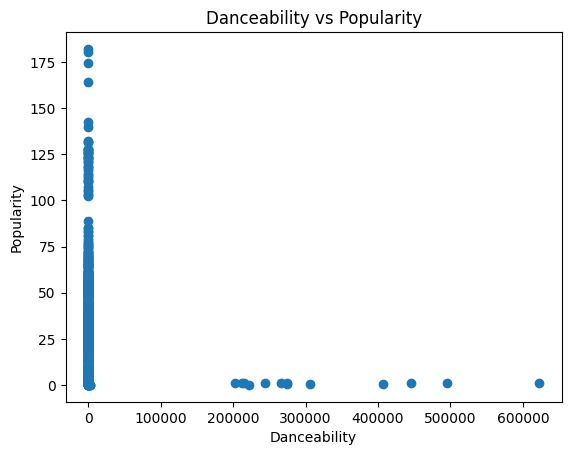

In [50]:
import matplotlib.pyplot as plt

plt.scatter(df_traduzido['Danceability'], df_traduzido['Popularity'])
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Danceability vs Popularity')
plt.savefig('projeto-analise-musicas/graficos/danceability.png')
plt.show()

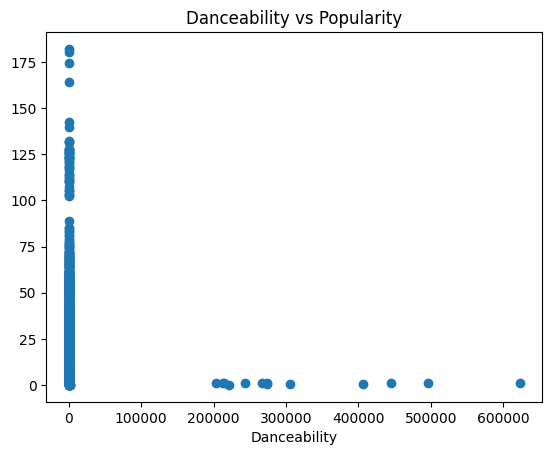

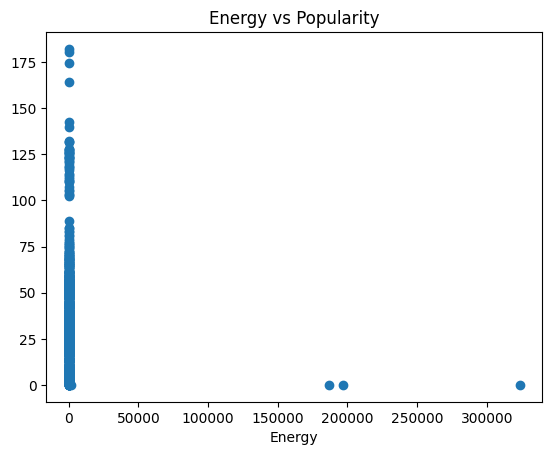

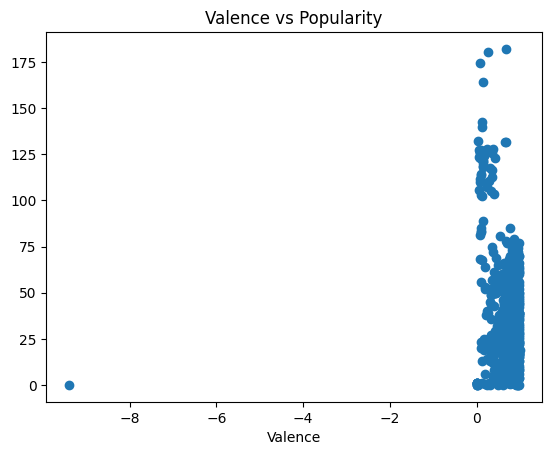

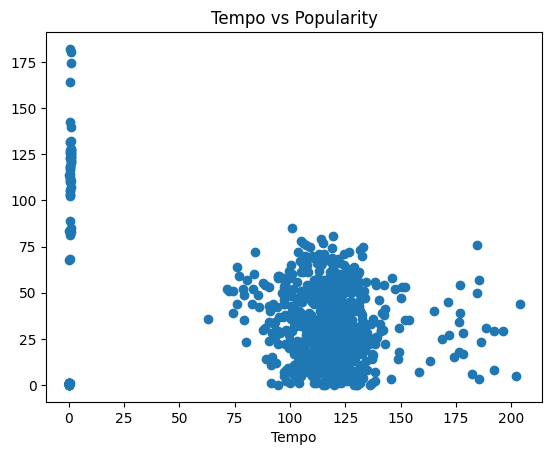

In [51]:
import matplotlib.pyplot as plt

variaveis = ['Danceability', 'Energy', 'Valence', 'Tempo']

for var in variaveis:
    plt.scatter(df_traduzido[var], df_traduzido['Popularity'])
    plt.title(f'{var} vs Popularity')
    plt.xlabel(var)
    plt.savefig(f'projeto-analise-musicas/graficos/{var}.png')
    plt.show()

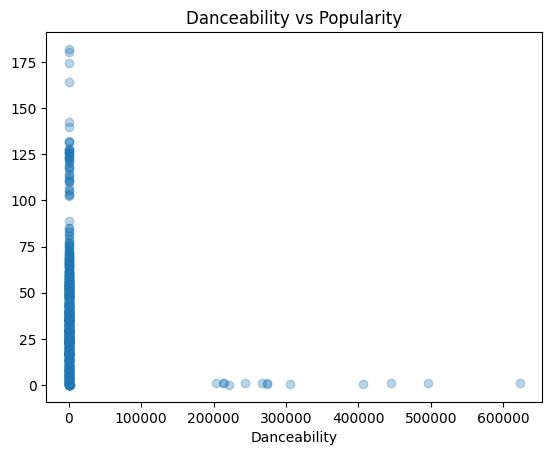

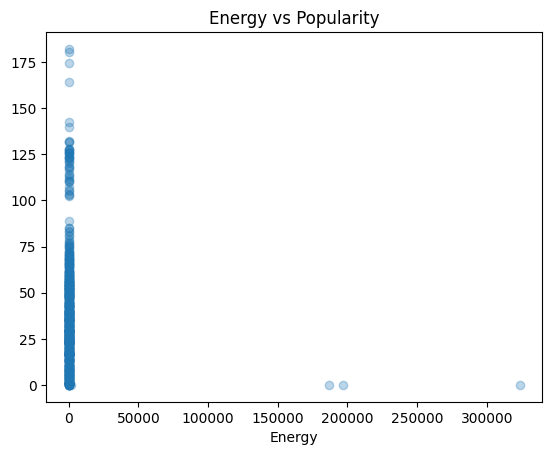

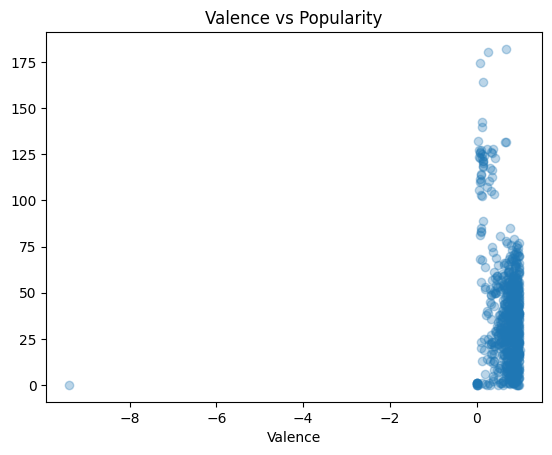

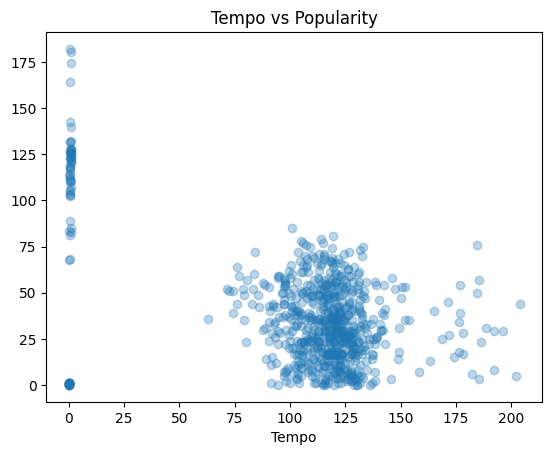

In [52]:
import matplotlib.pyplot as plt

variaveis = ['Danceability', 'Energy', 'Valence', 'Tempo']

for var in variaveis:
    plt.scatter(df_traduzido[var], df_traduzido['Popularity'], alpha=0.3)
    plt.title(f'{var} vs Popularity')
    plt.xlabel(var)
    plt.savefig(f'projeto-analise-musicas/graficos/{var}_transparente.png')
    plt.show()

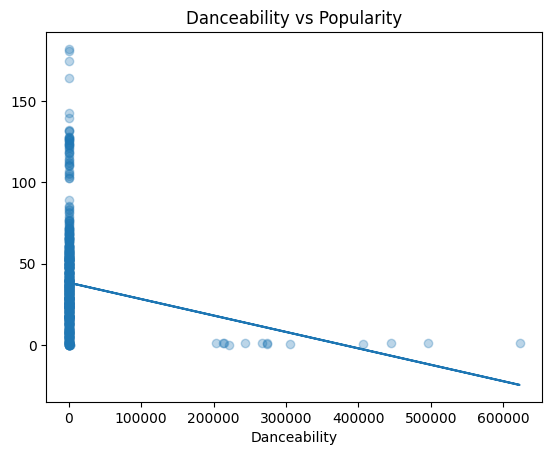

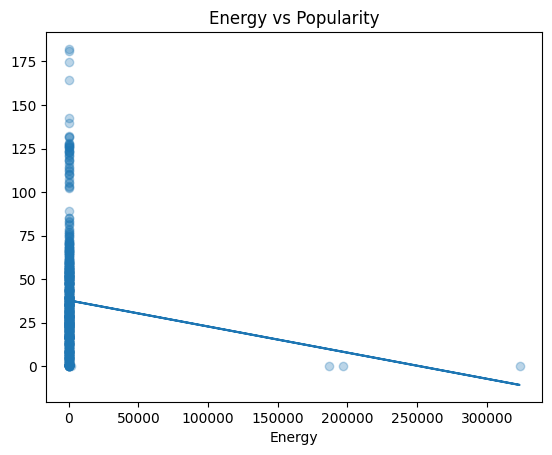

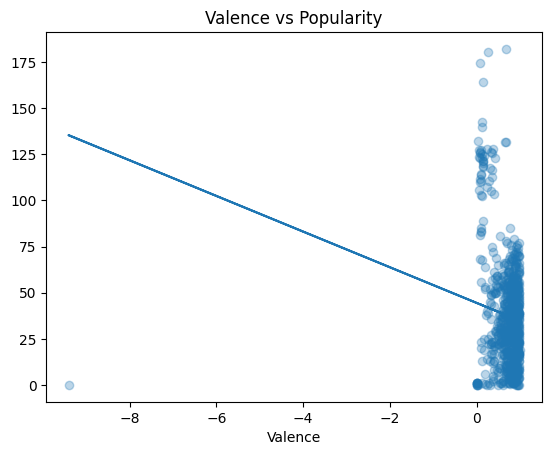

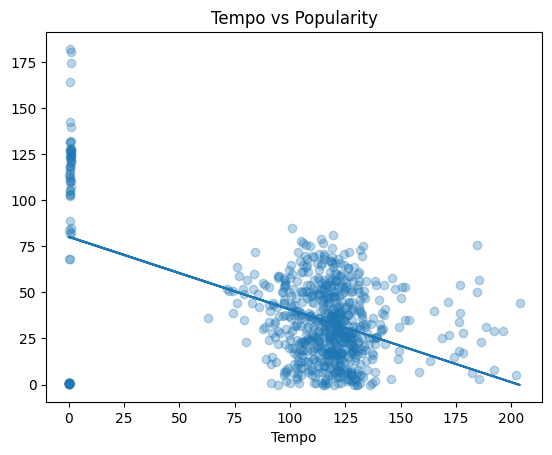

In [53]:
import numpy as np
import matplotlib.pyplot as plt

for var in variaveis:
    x = df_traduzido[var]
    y = df_traduzido['Popularity']
    
    plt.scatter(x, y, alpha=0.3)
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x))
    
    plt.title(f'{var} vs Popularity')
    plt.xlabel(var)
    # salvar
    plt.savefig(f'projeto-analise-musicas/graficos/{var}_tendencia.png')
    plt.show()

In [54]:
df_traduzido['Popularity'].describe()

count    722.000000
mean      37.690773
std       29.808379
min        0.000000
25%       17.000000
50%       32.000000
75%       51.000000
max      182.164000
Name: Popularity, dtype: float64

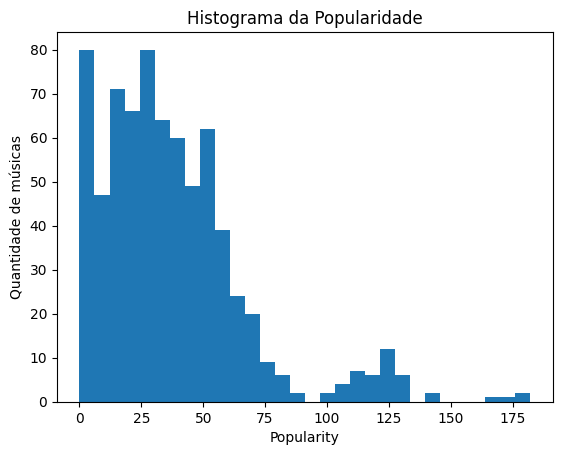

In [55]:
import matplotlib.pyplot as plt

plt.hist(df_traduzido['Popularity'], bins=30)
plt.title('Histograma da Popularidade')
plt.xlabel('Popularity')
plt.ylabel('Quantidade de músicas')
plt.savefig('projeto-analise-musicas/graficos/histograma_popularity.png')
plt.show()

In [56]:
df_traduzido = df_traduzido[df_traduzido['Popularity'] <= 100]

In [57]:
print(df_traduzido['Popularity'].describe())

correlacao = df_traduzido.corr(numeric_only=True)
print(correlacao['Popularity'].sort_values(ascending=False))

count    679.000000
mean      32.151517
std       20.167029
min        0.000000
25%       17.000000
50%       30.000000
75%       48.000000
max       88.941000
Name: Popularity, dtype: float64
Popularity            1.000000
Time_Signature        0.229384
Speechiness           0.133663
Valence               0.078603
Acousticness          0.037942
Instrumentalness      0.028444
Tempo                -0.002753
Liveness             -0.036066
ano                  -0.036621
Mode                 -0.061126
tonalidade           -0.061166
intensidade_sonora   -0.061843
Energy               -0.102743
Duration             -0.154865
Danceability         -0.202558
Name: Popularity, dtype: float64


In [58]:
import os
print(os.getcwd())

d:\HASHTAG\python_impressionador\projetos (DADOS)\discoteca pandas


vamos gerar agora um boxplot

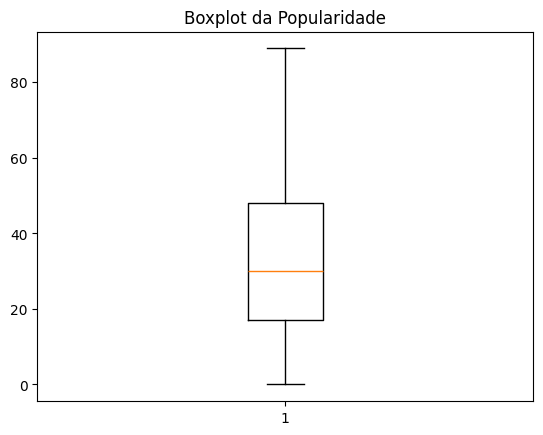

In [59]:
import matplotlib.pyplot as plt

plt.boxplot(df_traduzido['Popularity'])
plt.title('Boxplot da Popularidade')

plt.savefig('projeto-analise-musicas/graficos/boxplot_popularity.png')
plt.show()

In [60]:
# Salvando a base tratada
df_traduzido.to_excel('base_tratada.xlsx', index=False)

print("Base tratada salva com sucesso!")

Base tratada salva com sucesso!
